## 1) Importing libraries

In [26]:
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import numpy as np
import pathlib
import shutil
import os

import cv2 as cv
from functions import plots

In [18]:
random_state = 1

In [19]:
print(tf.__version__)

2.21.0


## 2) Reading data

<p>File names are stored in differents folders, each dataframe has its own <code>FILE NAME</code> column, where each file are named.</p>

### 2.1) Lung opacity

In [20]:
lung_df = pd.read_excel(
    io = "./dataset/COVID.metadata.xlsx"
)

print(lung_df.shape)
lung_df.head(2)

(3616, 4)


,FILE NAME,FORMAT,SIZE,URL
0,COVID-1,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
1,COVID-2,PNG,256*256,https://sirm.org/category/senza-categoria/covi...


### 2.2) Covid

In [21]:
covid_df = pd.read_excel(
    io = "./dataset/Lung_Opacity.metadata.xlsx"
)

print(covid_df.shape)
covid_df.head(2)

(6012, 4)


,FILE NAME,FORMAT,SIZE,URL
0,Lung_Opacity-1,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
1,Lung_Opacity-2,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...


### 2.3) Normal

In [22]:
normal_df = pd.read_excel(
    io = "./dataset/Normal.metadata.xlsx"
)

print(normal_df.shape)
normal_df.head(2)

(10192, 4)


,FILE NAME,FORMAT,SIZE,URL
0,NORMAL-1,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
1,NORMAL-2,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...


### 2.4) Viral Pneumonia

In [23]:
pneumonia_df = pd.read_excel(
    io = "./dataset/Viral Pneumonia.metadata.xlsx"
)

print(pneumonia_df.shape)
pneumonia_df.head(2)

(1345, 4)


,FILE NAME,FORMAT,SIZE,URL
0,Viral Pneumonia-1,PNG,256*256,https://www.kaggle.com/paultimothymooney/chest...
1,Viral Pneumonia-2,PNG,256*256,https://www.kaggle.com/paultimothymooney/chest...


### 2.5) Ploting images

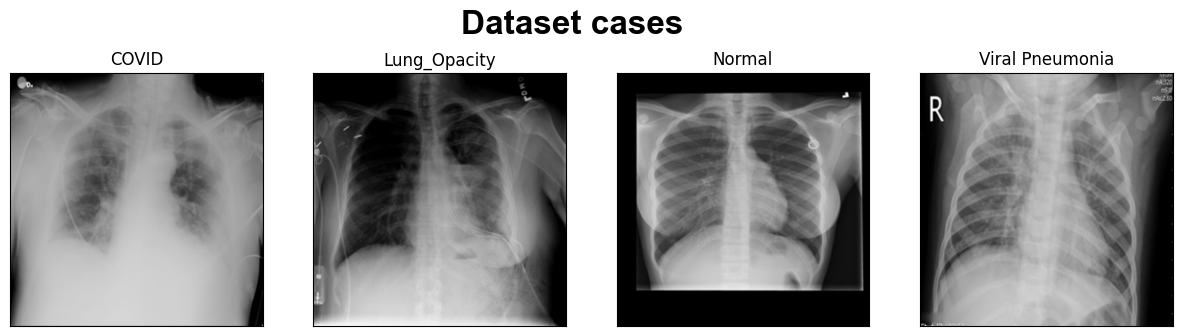

In [24]:
fig, axs = plt.subplots(
    ncols = 4,
    figsize = (15, 5)
)

axs = axs.flatten()

images = [
    "./dataset/COVID/images/COVID-1.png", "./dataset/Lung_Opacity/images/Lung_Opacity-1.png",
    "./dataset/Normal/images/Normal-1.png", "./dataset/Viral Pneumonia/images/Viral Pneumonia-1.png"
]

for index, image in enumerate(images):

    axs[index].imshow(
        cv.imread(filename = image)
    )
    axs[index].set_title(
        image.split(r"/")[-1].split("-")[0]
    )

for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle(t = "Dataset cases", fontsize = 24, fontweight = "bold", fontfamily = "arial", y = .875)
plt.show()

### 2.6) Plotting data categories

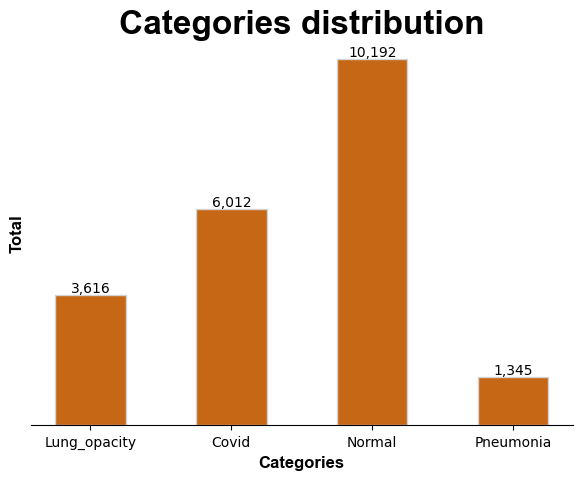

In [27]:
fig, ax = plt.subplots(
    figsize = (7, 5)
)

plots.plot_bar(
    ax = ax,
    x_values = ["Lung_opacity", "Covid", "Normal", "Pneumonia"],
    y_values = [len(lung_df), len(covid_df), len(normal_df), len(pneumonia_df)],
    colors = "#c56715",
    title = {
        "text": "Categories distribution",
        "size": 24
    },
    x_label = {
        "text": "Categories",
    },
    y_label = {
        "text": "Total"
    },
    legends = ["Lung_opacity", "Covid", "Normal", "Pneumonia"],
    tooltip_align = "edge"

)

plt.show()

## 3) Selecting

<p align="justify">Here, each category have differents lengths of collected data. Since now we are handling with classification - we are going to select an equal amount of data for each diagnosis, in order to create a model that will not have any preferences.</p>

### 3.1) Training

<p>For training, let's select <code>n = 1000</code> imagens for each category.</p>

In [20]:
n = 1000

train_names = np.concat([
    lung_df.sample(n = n, random_state = random_state)["FILE NAME"].values, 
    covid_df.sample(n = n, random_state = random_state)["FILE NAME"].values,
    normal_df.sample(n = n, random_state = random_state)["FILE NAME"].values,
    pneumonia_df.sample(n = n, random_state = random_state)["FILE NAME"].values
])

### 3.2) Testing

<p align="justify">For testing, let's select new <code>n = 200</code> samples for each category.</p>

In [21]:
n = 200

test_names = np.concat([
    lung_df[~lung_df["FILE NAME"].isin(values = train_names)].sample(n = n, random_state = random_state)["FILE NAME"].values, 
    covid_df[~covid_df["FILE NAME"].isin(values = train_names)].sample(n = n, random_state = random_state)["FILE NAME"].values,
    normal_df[~normal_df["FILE NAME"].isin(values = train_names)].sample(n = n, random_state = random_state)["FILE NAME"].values,
    pneumonia_df[~pneumonia_df["FILE NAME"].isin(values = train_names)].sample(n = n, random_state = random_state)["FILE NAME"].values
])

### 3.3) Validation

<p>At last, for validation, let's select only new <code>n = 100</code> samples for each category.</p>

In [22]:
n = 100

validation_names = np.concat([
    lung_df[~lung_df["FILE NAME"].isin(values = np.concat([train_names, test_names]))].sample(n = n, random_state = random_state)["FILE NAME"].values, 
    covid_df[~covid_df["FILE NAME"].isin(values = np.concat([train_names, test_names]))].sample(n = n, random_state = random_state)["FILE NAME"].values,
    normal_df[~normal_df["FILE NAME"].isin(values = np.concat([train_names, test_names]))].sample(n = n, random_state = random_state)["FILE NAME"].values,
    pneumonia_df[~pneumonia_df["FILE NAME"].isin(values = np.concat([train_names, test_names]))].sample(n = n, random_state = random_state)["FILE NAME"].values
])

## 4) Creating images folder

<p align = "justify">Knowing that the images are all stored in the <code>.dataset/images</code> folder, we will create a <code>chest-xray</code> folder - for example - that will stored all image files separately by category.</p>

### 4.1) Creating folders

In [23]:
if os.path.exists("./chest-xray"):
    shutil.rmtree("./chest-xray")
else:
    print("A pasta não existe.")

# Creating parent folder:
pathlib.Path("./chest-xray").mkdir(exist_ok = True)

# Creating subfolders:
pathlib.Path("./chest-xray/train").mkdir(exist_ok = True)
pathlib.Path("./chest-xray/test").mkdir(exist_ok = True)
pathlib.Path("./chest-xray/val").mkdir(exist_ok = True)


### 4.3) Insert images into subfolders

In [ ]:
target_size = (256, 256)

classes = ["Covid", "Lung Opacity", "Normal", "Pneumonia"]

for path in ["./chest-xray/train", "./chest-xray/test", "./chest-xray/val"]:

    for class_name in classes:
        pathlib.Path(f"{path}/{class_name}").mkdir(exist_ok = True)

for subfolder, split_name in [("train", train_names), ("test", test_names), ("val", validation_names)]:
    for path, name in zip(
        np.sort(
            np.array(
                classes*int(len(split_name)/len(classes))
            )
        ) + "/" + split_name
        ,
        split_name
    ):
        
        img = cv.imread(f"./dataset/images/{name}.png", cv.IMREAD_GRAYSCALE)
        img = cv.resize(src = img, dsize = target_size, interpolation = cv.INTER_CUBIC)

        mask = cv.imread(f"./dataset/masks/{name}.png", cv.IMREAD_GRAYSCALE)/255.0

        cv.imwrite(
            filename = f"./chest-xray/{subfolder}/{path}.png", img = img*mask
        )